In [ ]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# read the tables and merge
rater_one = pd.read_excel('/content/drive/MyDrive/EADH2026/groups_labeled_GPT-5_curation_Meriem.xlsx', index_col=0)
rater_two = pd.read_excel('/content/drive/MyDrive/EADH2026/groups_labeled_GPT-5_curation_Simone.xlsx', index_col=0)
full_df = rater_one.rename(columns={"curation": "Meriem"})
full_df["Simone"] = rater_two["curation"]
full_df["Simone_notes"] = rater_two["notes"]
full_df['curation'] = full_df.apply(lambda row: row["Meriem"] if row["Meriem"] == row["Simone"] else np.nan, axis=1)
#full_df.to_excel('/content/drive/MyDrive/EADH2026/groups_labeled_GPT-5_curation_full.xlsx')
full_df

,Sentences,GPT-5_Label,GPT-5_Label1,LLama-3_Label,LLama-3_Label1,Meriem,Simone,Simone_notes,curation
Group_Number,,,,,,,,,
51,The\nsupernatural being had not been touched a...,YES,NO,YES,NO,NO,NO,supernatural being? (but referring to previous...,NO
52,The people\nhad vanished. Mad terror had scatt...,YES,NO,YES,NO,NO,NO,NaN,NO
53,"I should think the cause of progress got them,...",NO,NO,NO,NO,NO,NO,cause of progress? Unclear,NO
54,In a very few hours I arrived in a city that a...,YES,NO,YES,YES,NO,YES,prejudice is mentioned explicitely,NaN
55,"It was the biggest thing in the town,\nand eve...",YES,YES,NO,NO,NO,NO,empire just mentioned,NO
...,...,...,...,...,...,...,...,...,...
146,The\nsick man was too ill to groan. The flies ...,NO,NO,NO,NO,NO,NO,NaN,NO
147,A caravan had come in. A violent babble of unc...,YES,YES,YES,YES,YES,YES,NaN,YES
148,"He rose slowly. ‘What a frightful row,’ he sai...",NO,NO,NO,NO,NO,NO,NaN,NO



Cohen's Kappa Score: 0.499


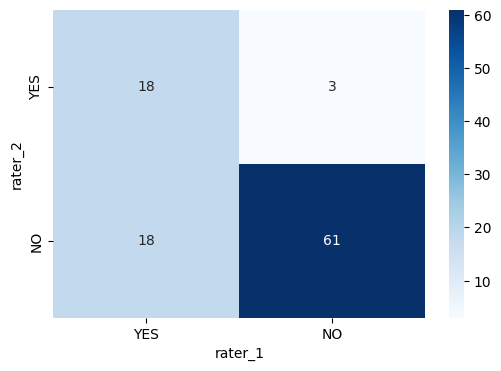

In [ ]:
# Kappa Score
kappa = cohen_kappa_score(full_df["Meriem"], full_df["Simone"])
print(f"\nCohen's Kappa Score: {kappa:.3f}")

# Confusion Matrix
cm_correct = confusion_matrix(full_df["Meriem"], full_df["Simone"], labels=["YES", "NO"])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_correct, annot=True, fmt='d', cmap='Blues', xticklabels=["YES", "NO"], yticklabels=["YES", "NO"])
plt.xlabel("rater_1")
plt.ylabel("rater_2")
#plt.title('Confusion Matrix')
plt.show()



###### GPT-5_Label 



Cohen's Kappa Score: 0.240


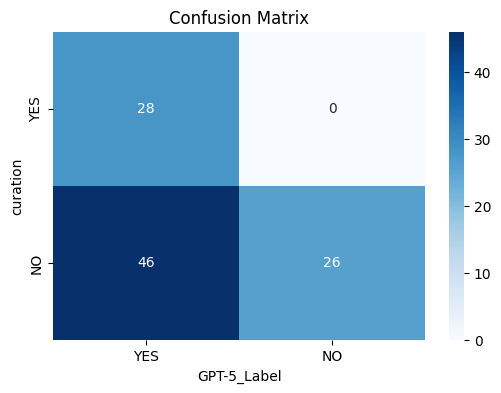

              precision    recall  f1-score   support

          NO       1.00      0.36      0.53        72
         YES       0.38      1.00      0.55        28

    accuracy                           0.54       100
   macro avg       0.69      0.68      0.54       100
weighted avg       0.83      0.54      0.54       100



###### GPT-5_Label1 



Cohen's Kappa Score: 0.649


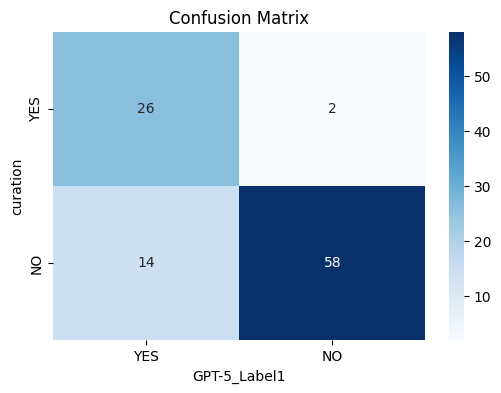

              precision    recall  f1-score   support

          NO       0.97      0.81      0.88        72
         YES       0.65      0.93      0.76        28

    accuracy                           0.84       100
   macro avg       0.81      0.87      0.82       100
weighted avg       0.88      0.84      0.85       100



###### LLama-3_Label 



Cohen's Kappa Score: 0.578


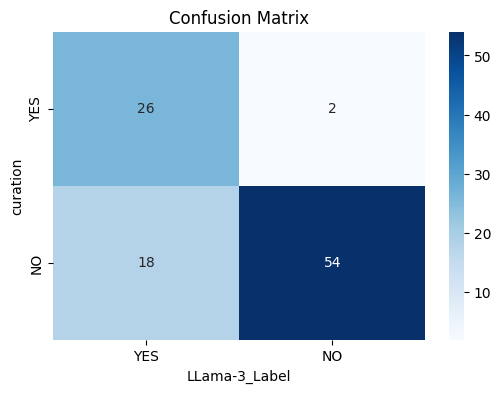

              precision    recall  f1-score   support

          NO       0.96      0.75      0.84        72
         YES       0.59      0.93      0.72        28

    accuracy                           0.80       100
   macro avg       0.78      0.84      0.78       100
weighted avg       0.86      0.80      0.81       100



###### LLama-3_Label1 



Cohen's Kappa Score: 0.624


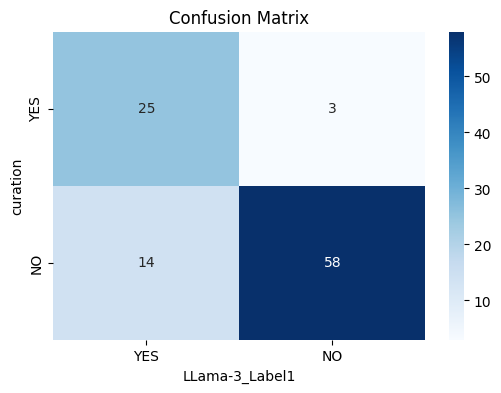

              precision    recall  f1-score   support

          NO       0.95      0.81      0.87        72
         YES       0.64      0.89      0.75        28

    accuracy                           0.83       100
   macro avg       0.80      0.85      0.81       100
weighted avg       0.86      0.83      0.84       100



In [ ]:
# read curation df

curation_df = pd.read_excel('/content/drive/MyDrive/EADH2026/groups_labeled_GPT-5_curation_full.xlsx')

for my_model in ["GPT-5_Label",	"GPT-5_Label1",	"LLama-3_Label", "LLama-3_Label1"]:

  print("\n\n######", my_model, "\n\n")
  # Kappa Score
  kappa = cohen_kappa_score(curation_df["curation"], curation_df[my_model])
  print(f"\nCohen's Kappa Score: {kappa:.3f}")

  # Confusion Matrix
  cm_correct = confusion_matrix(curation_df["curation"], curation_df[my_model], labels=["YES", "NO"])
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm_correct, annot=True, fmt='d', cmap='Blues', xticklabels=["YES", "NO"], yticklabels=["YES", "NO"])
  plt.xlabel(my_model)
  plt.ylabel("curation")
  plt.title('Confusion Matrix')
  plt.show()

  # precision/recall
  print(classification_report(curation_df["curation"],
                            curation_df[my_model]))
